# Visualization of Log Probabilities for Steering Self Preference

This notebook is for making histogram visualizations of log probability distributions that a model would choose its own output. The distributions are unfiltered, meaning that in the total set there is no clear wrong or clear right answer.

In [1]:
import json
with open("qwen_0.6_v_deepseek_distill.jsonl", "r") as f:
    cnn_scores = [json.loads(line) for line in f.readlines()]
# with open("dbg_scores/xsum.jsonl", "r") as f:
#     xsum_scores = [json.loads(line) for line in f.readlines()]
# with open("dbg_scores/xsum_conscious.jsonl", "r") as f:
#     xsum_conscious_scores = [json.loads(line) for line in f.readlines()]
# with open("dbg_scores/xsum_aware.jsonl", "r") as f:
#     xsum_aware_scores = [json.loads(line) for line in f.readlines()]
#     xsum_objective = .477
# with open("dbg_scores/apps.jsonl", "r") as f:
#     apps_scores = [json.loads(line) for line in f.readlines()]
#     apps_objective = .387

In [2]:
def prob_list(scores):
    count = 0
    total = 0
    examples = {
        "lsp": [],
        "ilsp": []
    }
    for s in scores:
        total += 1
        if s['probabilities']['RJ_order'] == {'A': 0.0, 'B': 0.0, 'T': 0.0}:
            count += 1
            continue
        AB_normalized = s['probabilities']['RJ_order']["B"] / (s['probabilities']['RJ_order']["A"] + s['probabilities']['RJ_order']["B"])
        pref_type = 'lsp' if s['judge_correct']==1 else 'ilsp'
        examples[pref_type].append(AB_normalized)
    return examples, len(examples['lsp']) / (len(examples['lsp']) + len(examples['ilsp']))



<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/var/folders/th/r_z7m5js0_z5lgk1tlr478p40000gn/T/ipykernel_37972/3554532624.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.axvline(mean, color='black', linestyle='--', label = "$\mu$")
/var/folders/th/r_z7m5js0_z5lgk1tlr478p40000gn/T/ipykernel_37972/3554532624.py:34: SyntaxWarning: invalid escape sequence '\m'
  subtitle = f"$\mu: {mean:.2f}$ | Judge Score: {objective:.2f}"


NameError: name 'xsum_scores' is not defined

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

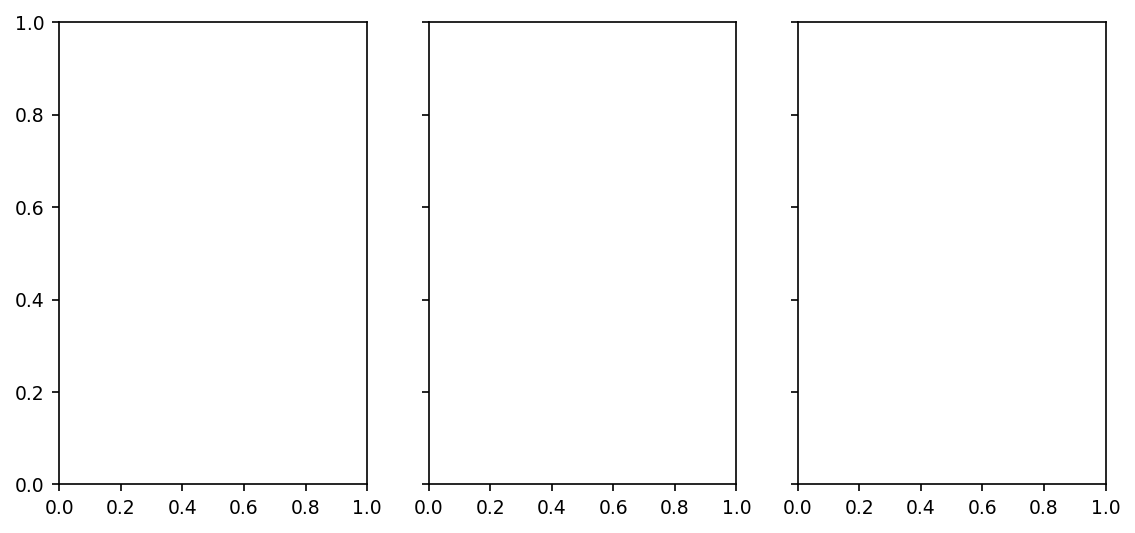

In [49]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ['Liberation Sans'],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})
def plot_histogram_with_stats(ax, data, objective, title=None, xlabel=None, no_spine = False, **hist_kwargs):
    
    # Calculate mean and bootstrap CI
    mean = np.mean(data)
    # Ensure data is a 1D array for bootstrapping
    res = bootstrap((np.array(data),), np.mean) 
    CI = res.confidence_interval
    
    # Plotting
    ax.hist(data, **hist_kwargs)
    ax.axvline(mean, color='black', linestyle='--', label = "$\mu$")
    ax.axvline(objective, color='red', linestyle='--', label= "Judge Score")
    
    # --- IMPROVEMENT 1: Plot the CI directly ---
    ax.axvspan(CI.low, CI.high, alpha=0.2, color='orange')
    
    if title:
        ax.set_title(title, fontweight='bold', fontsize=12, pad=18)
        
        # --- IMPROVEMENT 2: Clearer subtitle ---
        subtitle = f"$\mu: {mean:.2f}$ | Judge Score: {objective:.2f}"
        ax.text(0.5, 1.0, subtitle,
                ha='center',            
                va='bottom',            
                transform=ax.transAxes,
                fontsize=9,
                color='gray')

    if xlabel:
        ax.set_xlabel(xlabel)
    if no_spine:
        ax.spines['left'].set_visible(False)
        
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(ncols = 3, figsize=(9, 4), sharey=True)

plot_histogram_with_stats(
    ax=ax[0], 
    data=prob_list(xsum_scores), 
    objective = xsum_objective,
    title="XSUM, Blind", 
    xlabel="$P(self)$",
    bins=20,
    color='cornflowerblue',
    edgecolor='white',
    linewidth=0.5
)

plot_histogram_with_stats(
    ax=ax[1], 
    data=prob_list(xsum_aware_scores), 
    objective = xsum_objective,
    title="XSUM, Aware", 
    xlabel="$P(self)$",
    bins=20,
    color='cornflowerblue',
    edgecolor='white',
    linewidth=0.5,
    no_spine = True
)

plot_histogram_with_stats(
    ax=ax[2], 
    data=prob_list(xsum_conscious_scores), 
    objective = xsum_objective,
    title="XSUM, Conscious", 
    xlabel="$P(self)$",
    bins=20,
    color='cornflowerblue',
    edgecolor='white',
    linewidth=0.5,
    no_spine = True
)

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

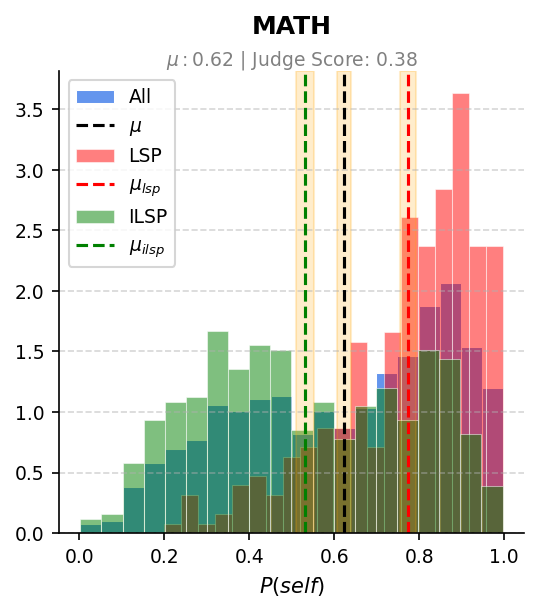

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

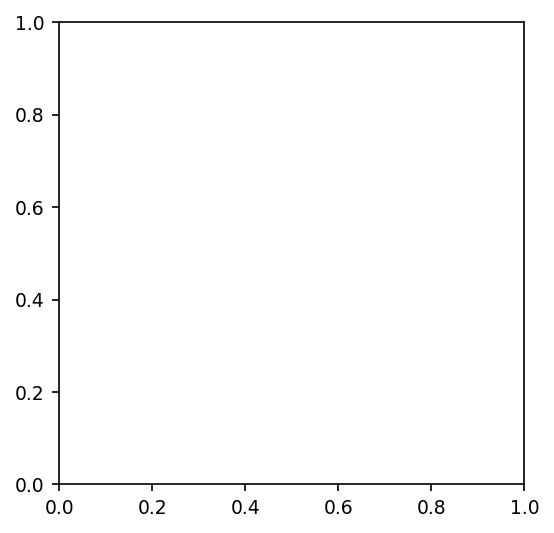

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ['Liberation Sans'],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})
def plot_histogram_with_stats(ax, data, objective, title=None, xlabel=None, no_spine = False, **hist_kwargs):

    # Separate LSP and ILSP examples
    lsp_data = data.get("lsp", [])
    ilsp_data = data.get("ilsp", [])

    full_data = lsp_data + ilsp_data
    # Calculate mean and bootstrap CI
    mean = np.mean(full_data)
    # Ensure data is a 1D array for bootstrapping
    res = bootstrap((np.array(full_data),), np.mean) 
    CI = res.confidence_interval
    
    mean_lsp = np.mean(lsp_data)
    # Ensure data is a 1D array for bootstrapping
    res = bootstrap((np.array(lsp_data),), np.mean) 
    CI_lsp = res.confidence_interval

    mean_ilsp = np.mean(ilsp_data)
    # Ensure data is a 1D array for bootstrapping
    res = bootstrap((np.array(ilsp_data),), np.mean)
    CI_ilsp = res.confidence_interval

    # Plotting
    ax.hist(full_data, **hist_kwargs, color='cornflowerblue', label="All")
    ax.axvline(mean, color='black', linestyle='--', label = "$\mu$")

    ax.hist(lsp_data, **hist_kwargs, color='red', alpha=0.5, label='LSP')
    ax.axvline(mean_lsp, color='red', linestyle='--', label = "$\mu_{lsp}$")
    ax.hist(ilsp_data, **hist_kwargs, color='green', alpha=0.5, label='ILSP')
    ax.axvline(mean_ilsp, color='green', linestyle='--', label = "$\mu_{ilsp}$")
    
    # --- IMPROVEMENT 1: Plot the CI directly ---
    ax.axvspan(CI.low, CI.high, alpha=0.2, color='orange')
    ax.axvspan(CI_lsp.low, CI_lsp.high, alpha=0.2, color='orange')
    ax.axvspan(CI_ilsp.low, CI_ilsp.high, alpha=0.2, color='orange')

    if title:
        ax.set_title(title, fontweight='bold', fontsize=12, pad=18)
        
        # --- IMPROVEMENT 2: Clearer subtitle ---
        subtitle = f"$\mu: {mean:.2f}$ | Judge Score: {objective:.2f}"
        ax.text(0.5, 1.0, subtitle,
                ha='center',            
                va='bottom',            
                transform=ax.transAxes,
                fontsize=9,
                color='gray')

    if xlabel:
        ax.set_xlabel(xlabel)
    if no_spine:
        ax.spines['left'].set_visible(False)
        
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, ax = plt.subplots(figsize=(4, 4), sharey=True)

plot_histogram_with_stats(
    ax=ax,
    data=prob_list(cnn_scores)[0], 
    objective=prob_list(cnn_scores)[1],
    title="MATH", 
    xlabel="$P(self)$",
    density=True,
    bins=20,
    edgecolor='white',
    linewidth=0.5
)
plt.legend()
plt.show()
fig, ax = plt.subplots(figsize=(4, 4), sharey=True)

# plot_histogram_with_stats(
#     ax=ax,
#     data=prob_list(apps_scores), 
#     objective=apps_objective,
#     title="APPS, Blind", 
#     xlabel="$P(self)$",
#     bins=20,
#     color='cornflowerblue',
#     edgecolor='white',
#     linewidth=0.5
# )

# plt.legend()
# plt.show()

In [77]:
np.mean(np.array(prob_list(cnn_scores)) > 0.5)

np.float64(0.902)